In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [4]:
df = pd.read_csv('../Data/churnsense.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [7]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].mean())

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.000,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.000,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.500,70.35,89.85,118.75
TotalCharges,7043.0,2283.300441,2265.000258,18.80,402.225,1400.55,3786.60,8684.80


In [11]:
df.drop(columns=["customerID"], inplace=True)

In [12]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

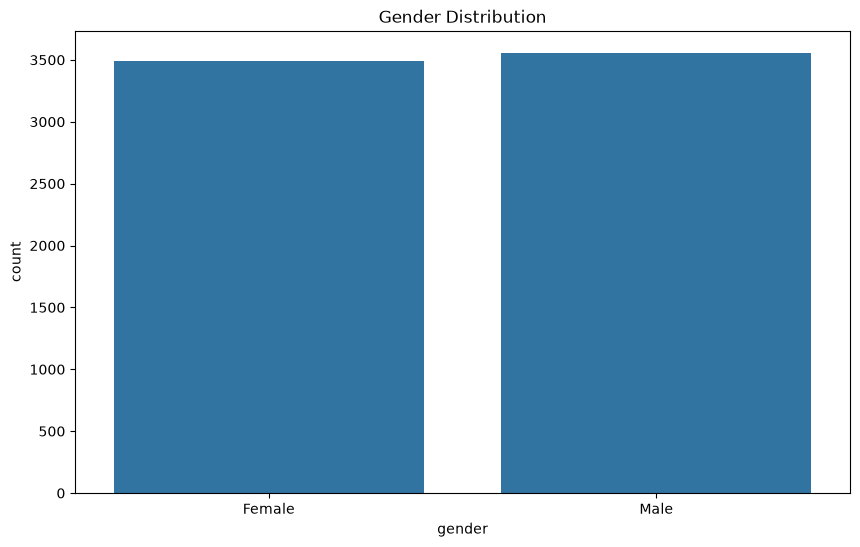

In [13]:
import os

plt.figure(figsize=(10, 6))
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
os.makedirs("reports", exist_ok=True)
plt.savefig("reports/gender_distribution.png")
plt.show()

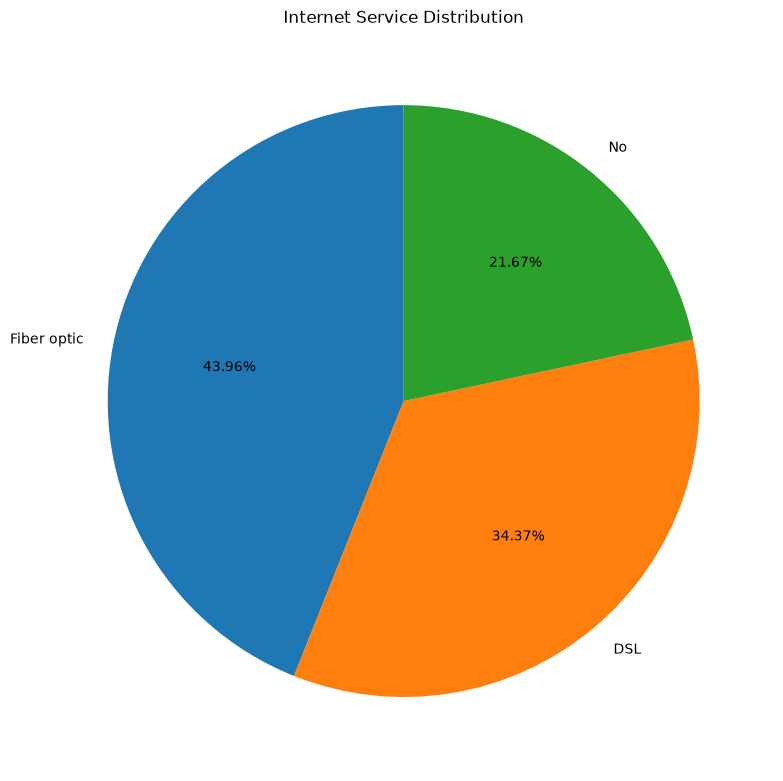

In [14]:
internet_service_counts = df["InternetService"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(
    internet_service_counts,
    labels=internet_service_counts.index,
    autopct="%1.2f%%",
    startangle=90
)
plt.title("Internet Service Distribution")
plt.tight_layout()
plt.savefig("reports/internet_service_distribution.png")
plt.show()

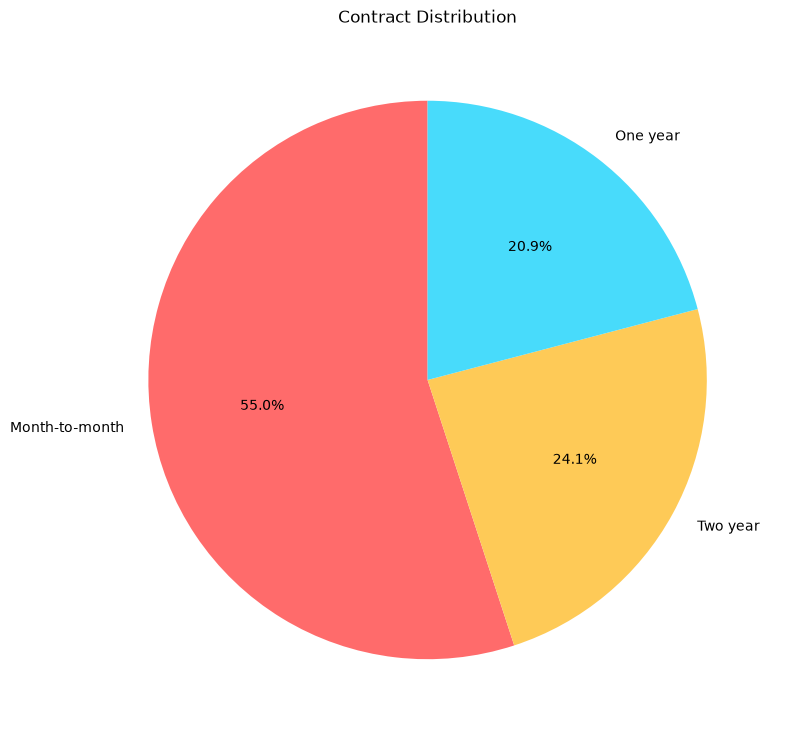

In [15]:
contract_counts = df["Contract"].value_counts()

plt.figure(figsize=(8, 8))
_, _, autotexts = plt.pie(
    contract_counts,
    labels=contract_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#ff6b6b", "#feca57", "#48dbfb"],
)
plt.title("Contract Distribution")
plt.tight_layout()
plt.savefig("reports/contract_distribution.png")
plt.show()


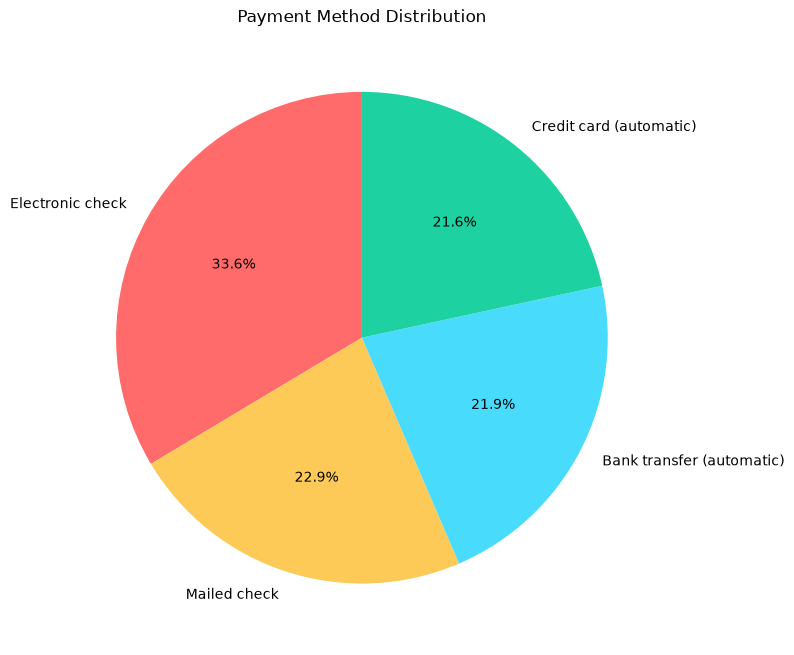

In [16]:
paymentmethod_counts = df["PaymentMethod"].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 8))
plt.pie(
    paymentmethod_counts,
    labels=paymentmethod_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#ff6b6b", "#feca57", "#48dbfb", "#1dd1a1", "#c56cf0"],
)
plt.title("Payment Method Distribution")
plt.tight_layout()
plt.savefig("reports/paymentmethod_distribution.png")
plt.show()

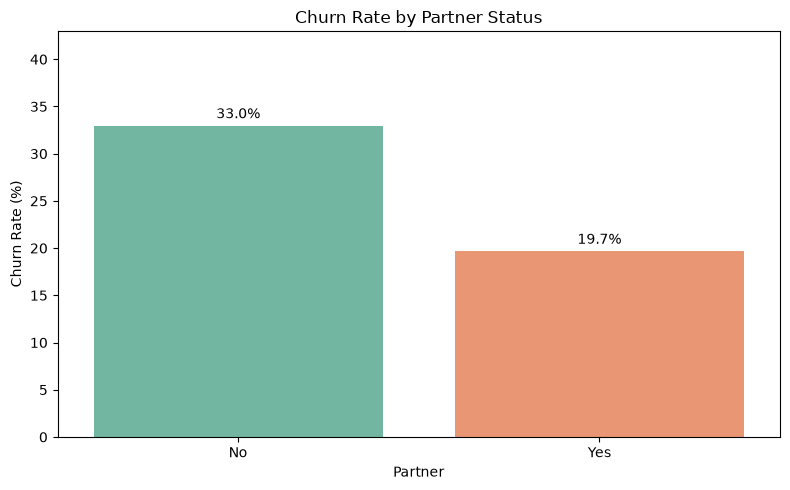

In [17]:
churn_rate_partner = (
    df.assign(Churned=df["Churn"].eq("Yes"))
      .groupby("Partner")["Churned"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=churn_rate_partner.index,
    y=churn_rate_partner.values,
    hue=churn_rate_partner.index,
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, churn_rate_partner.max() + 10)
plt.tight_layout()
plt.savefig("reports/churn_rate_by_partner.png")
plt.show()

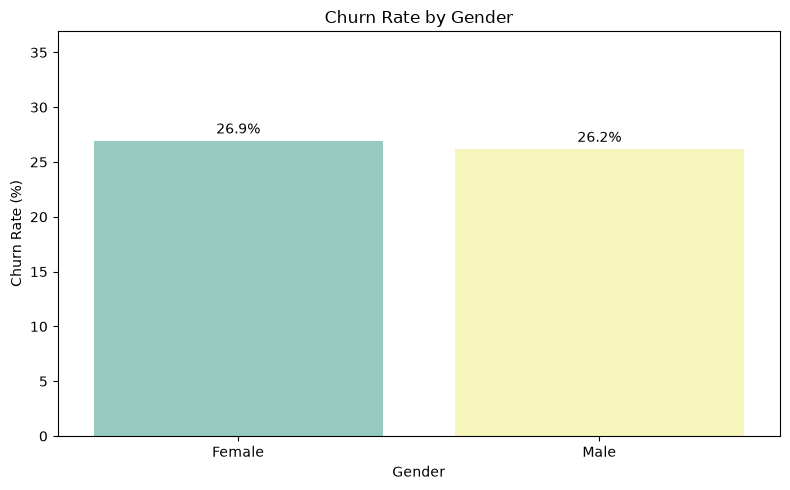

In [18]:
churn_rate_gender = (
    df.assign(Churned=df["Churn"].eq("Yes"))
      .groupby("gender")["Churned"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=churn_rate_gender.index,
    y=churn_rate_gender.values,
    hue=churn_rate_gender.index,
    palette="Set3",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, churn_rate_gender.max() + 10)
plt.tight_layout()
plt.savefig("reports/churn_rate_by_gender.png")
plt.show()

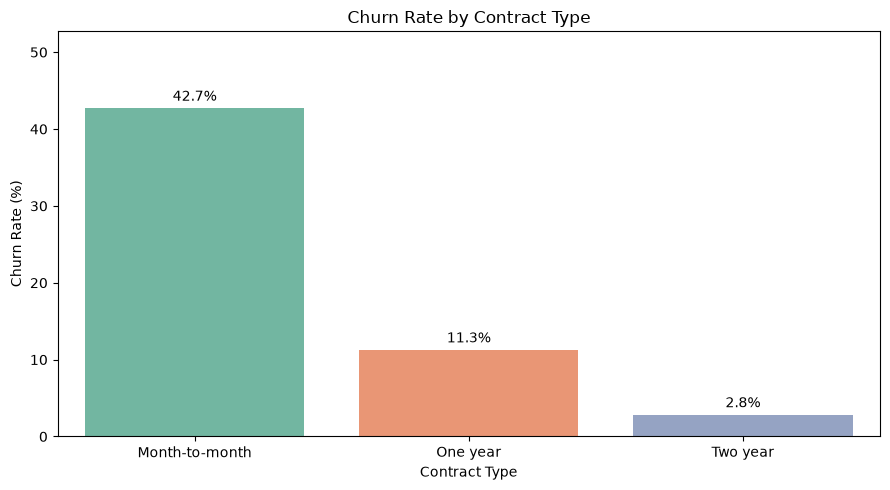

In [19]:
churn_rate_contract = (
    df.assign(Churned=df["Churn"].eq("Yes"))
      .groupby("Contract")["Churned"]
      .mean()
      .mul(100)
      .reindex(["Month-to-month", "One year", "Two year"])
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=churn_rate_contract.index,
    y=churn_rate_contract.values,
    hue=churn_rate_contract.index,
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, churn_rate_contract.max() + 10)
plt.tight_layout()

plt.savefig("reports/churn_rate_by_contract.png", dpi=300, bbox_inches="tight")
plt.show()

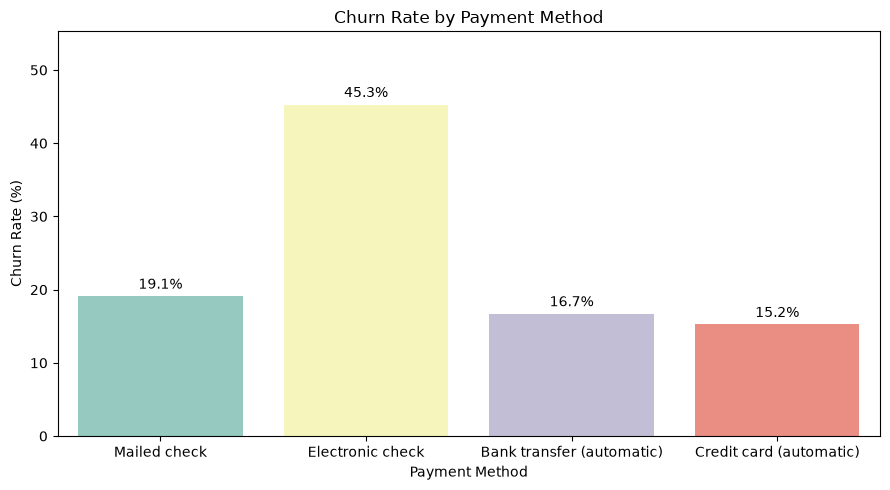

In [20]:
churn_rate_PaymentMethod = (
    df.assign(Churned=df["Churn"].eq("Yes"))
      .groupby("PaymentMethod")["Churned"]
      .mean()
      .mul(100)
      .reindex(["Mailed check", "Electronic check", "Bank transfer (automatic)", "Credit card (automatic)"])
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=churn_rate_PaymentMethod.index,
    y=churn_rate_PaymentMethod.values,
    hue=churn_rate_PaymentMethod.index,
    palette="Set3",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, churn_rate_PaymentMethod.max() + 10)
plt.tight_layout()

plt.savefig("reports/churn_rate_by_payment_method.png", dpi=300, bbox_inches="tight")
plt.show()

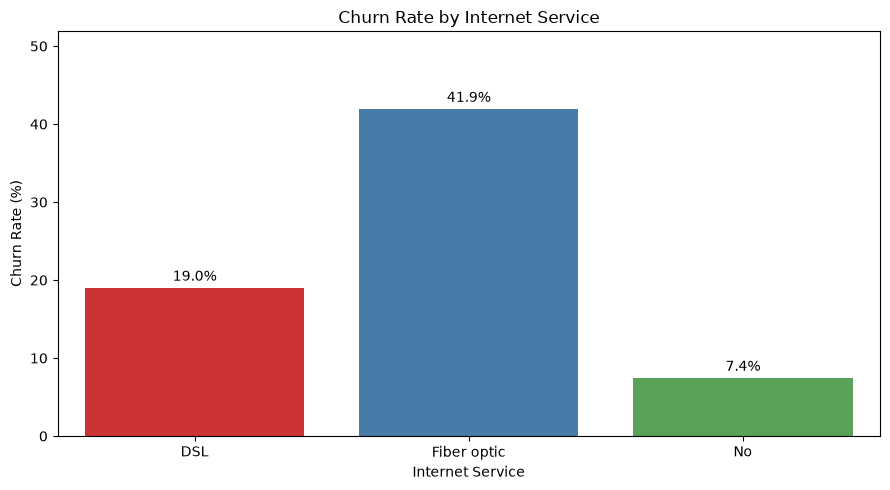

In [21]:
churn_rate_Internet = (
    df.assign(Churned=df["Churn"].eq("Yes"))
      .groupby("InternetService")["Churned"]
      .mean()
      .mul(100)
      .reindex(["DSL", "Fiber optic", "No"])
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=churn_rate_Internet.index,
    y=churn_rate_Internet.values,
    hue=churn_rate_Internet.index,
    palette="Set1",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, churn_rate_Internet.max() + 10)
plt.tight_layout()

plt.savefig("reports/churn_rate_by_internet_service.png", dpi=300, bbox_inches="tight")
plt.show()

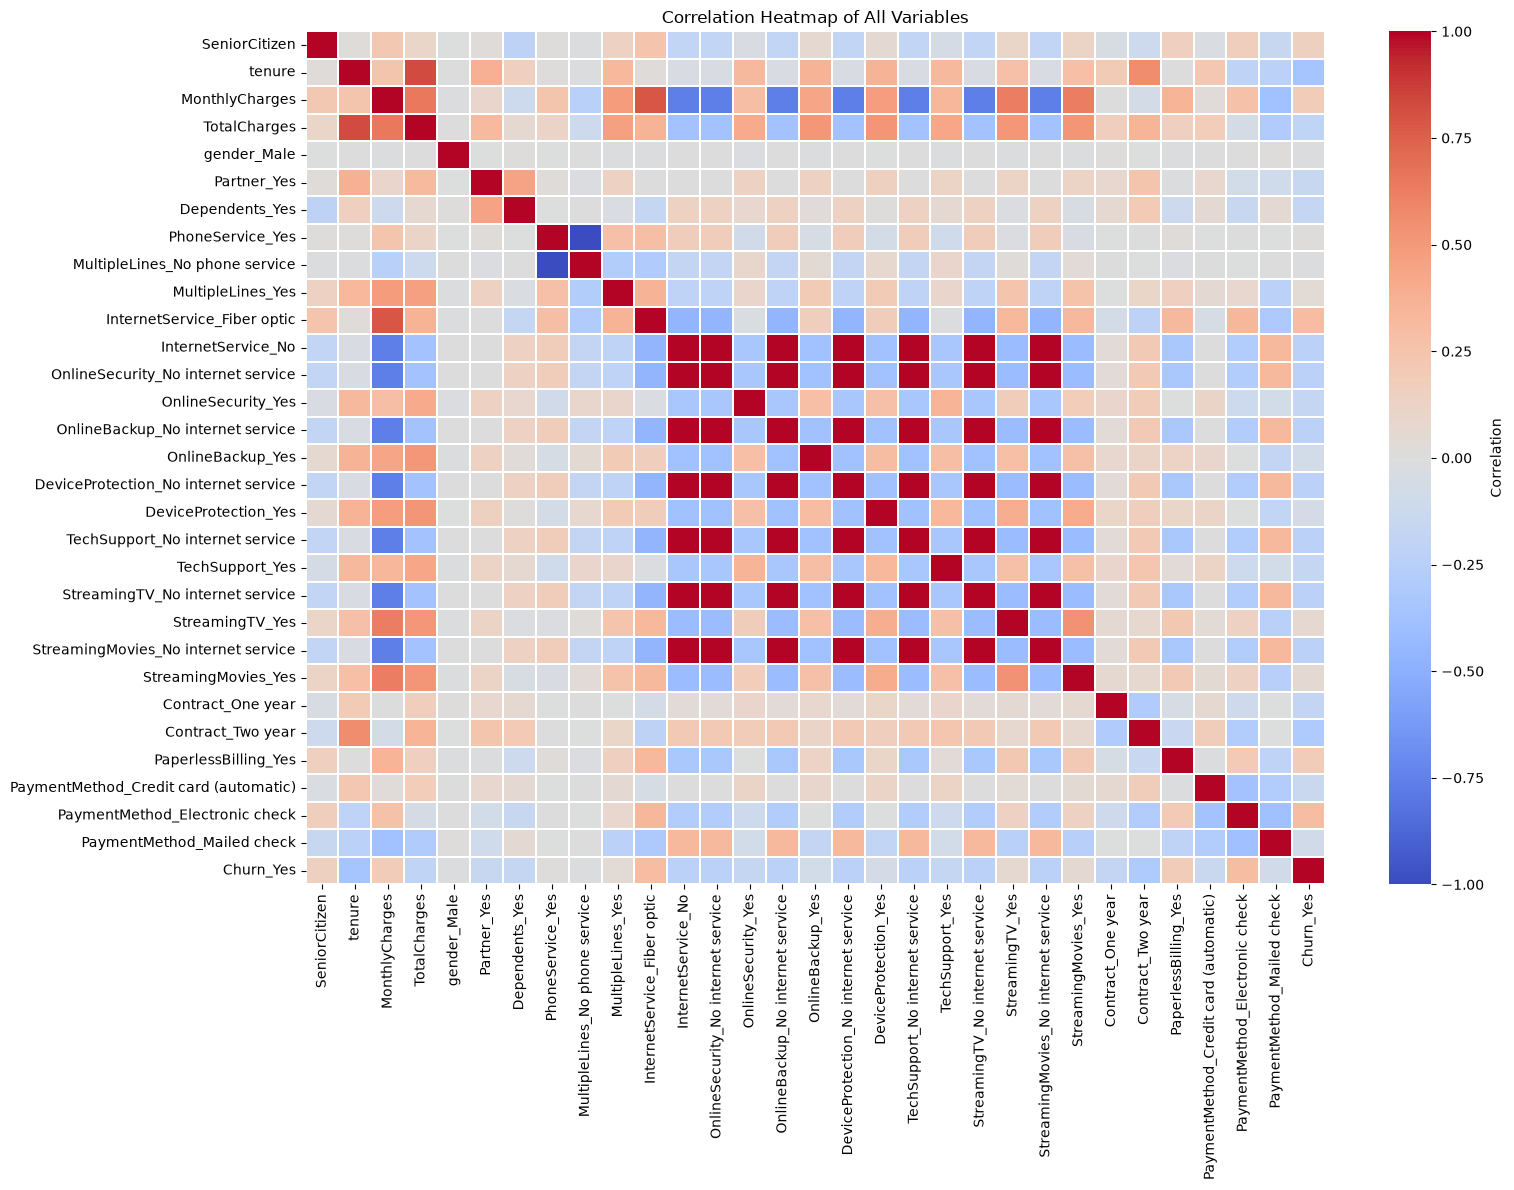

In [22]:
df_encoded = pd.get_dummies(df, drop_first=True, dtype=int)

correlation_matrix = df_encoded.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Heatmap of All Variables")
plt.tight_layout()
plt.savefig("reports/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

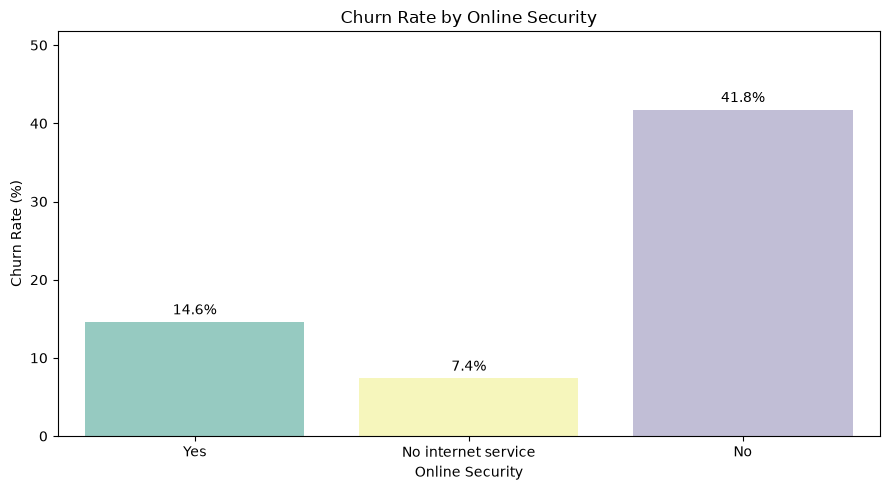

In [24]:
churn_rate_Onlinesecurity = (
    df.assign(Churned=df["Churn"].eq("Yes"))
      .groupby("OnlineSecurity")["Churned"]
      .mean()
      .mul(100)
      .reindex(["Yes", "No internet service", "No"])
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=churn_rate_Onlinesecurity.index,
    y=churn_rate_Onlinesecurity.values,
    hue=churn_rate_Onlinesecurity.index,
    palette="Set3",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, churn_rate_Onlinesecurity.max() + 10)
plt.tight_layout()

plt.savefig("reports/churn_rate_by_online_security.png", dpi=300, bbox_inches="tight")
plt.show()

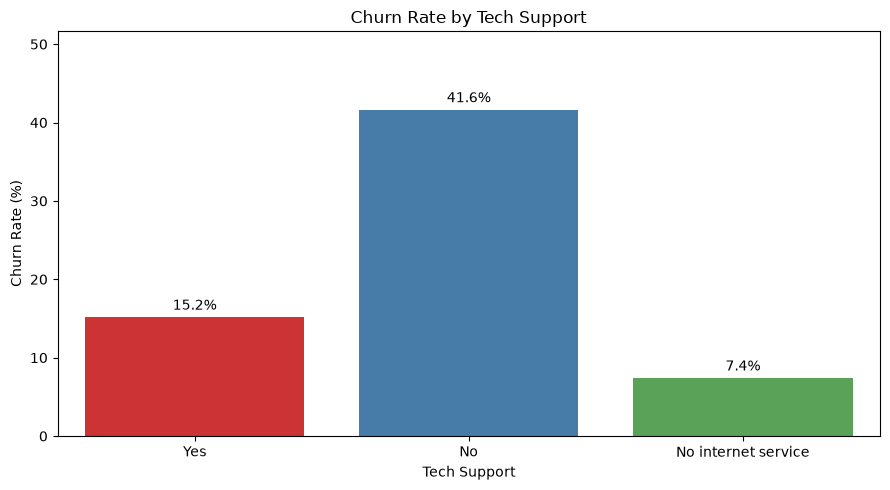

In [26]:
churn_rate_TechSupport = (
    df.assign(Churned=df["Churn"].eq("Yes"))
      .groupby("TechSupport")["Churned"]
      .mean()
      .mul(100)
      .reindex(["Yes", "No", "No internet service"])
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=churn_rate_TechSupport.index,
    y=churn_rate_TechSupport.values,
    hue=churn_rate_TechSupport.index,
    palette="Set1",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, churn_rate_TechSupport.max() + 10)
plt.tight_layout()

plt.savefig("reports/churn_rate_by_tech_support.png", dpi=300, bbox_inches="tight")
plt.show()

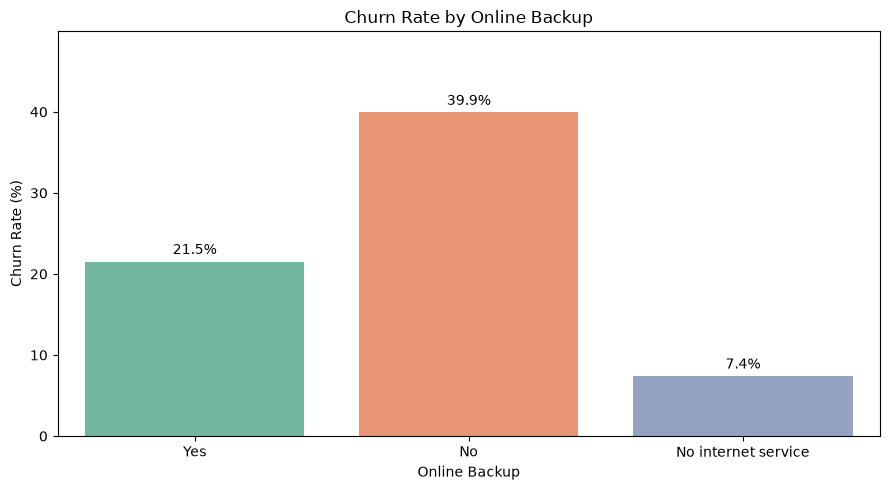

In [28]:
churn_rate_OnlineBackup = (
    df.assign(Churned=df["Churn"].eq("Yes"))
      .groupby("OnlineBackup")["Churned"]
      .mean()
      .mul(100)
      .reindex(["Yes", "No", "No internet service"])
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=churn_rate_OnlineBackup.index,
    y=churn_rate_OnlineBackup.values,
    hue=churn_rate_OnlineBackup.index,
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Churn Rate by Online Backup")
plt.xlabel("Online Backup")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, churn_rate_OnlineBackup.max() + 10)
plt.tight_layout()

plt.savefig("reports/churn_rate_by_online_backup.png", dpi=300, bbox_inches="tight")
plt.show()

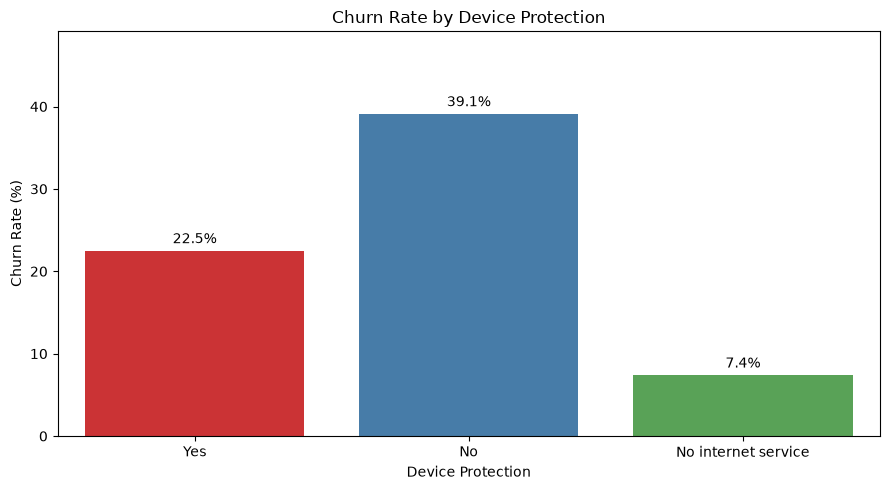

In [30]:
churn_rate_DeviceProtection = (
    df.assign(Churned=df["Churn"].eq("Yes"))
      .groupby("DeviceProtection")["Churned"]
      .mean()
      .mul(100)
      .reindex(["Yes", "No", "No internet service"])
)



plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=churn_rate_DeviceProtection.index,
    y=churn_rate_DeviceProtection.values,
    hue=churn_rate_DeviceProtection.index,
    palette="Set1",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Churn Rate by Device Protection")
plt.xlabel("Device Protection")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, churn_rate_DeviceProtection.max() + 10)
plt.tight_layout()

plt.savefig("reports/churn_rate_by_device_protection.png", dpi=300, bbox_inches="tight")
plt.show()

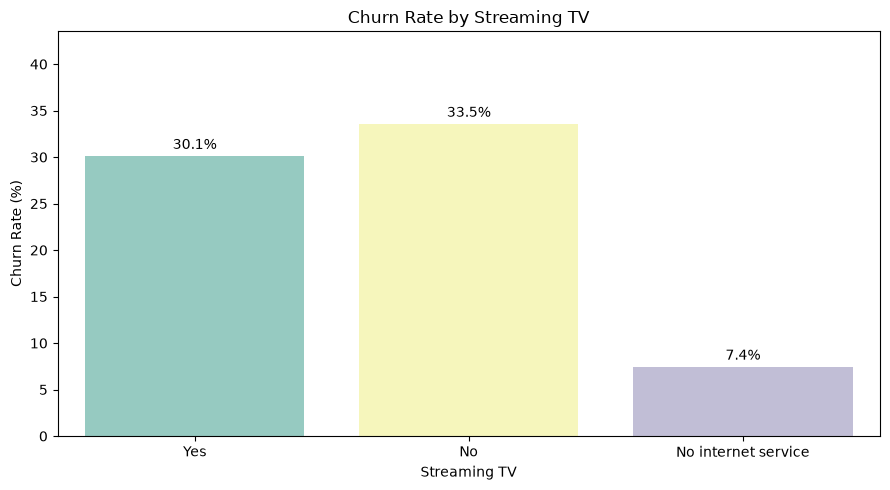

In [32]:
churn_rate_Streaming = (
    df.assign(Churned=df["Churn"].eq("Yes"))
      .groupby("StreamingTV")["Churned"]
      .mean()
      .mul(100)
      .reindex(["Yes", "No", "No internet service"])
)

plt.figure(figsize=(9, 5))
ax = sns.barplot(
    x=churn_rate_Streaming.index,
    y=churn_rate_Streaming.values,
    hue=churn_rate_Streaming.index,
    palette="Set3",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Churn Rate by Streaming TV")
plt.xlabel("Streaming TV")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, churn_rate_Streaming.max() + 10)
plt.tight_layout()

plt.savefig("reports/churn_rate_by_streaming_tv.png", dpi=300, bbox_inches="tight")
plt.show()